# 🚀 End-to-End Feature Engineering Project

## 📊 Problem: Stock Return Prediction (Using Yahoo Finance data)

We’ll build a **feature engineering pipeline** on stock data (e.g., AAPL / TCS / GOOG/  any stock via `yfinance`) and prepare it for modeling.

---

# 🧠 1. Project Objective

* Predict **next-day returns**
* Build **robust features**
* Handle **skewness, scaling, encoding**
* Use **pipeline-based preprocessing**

---

# 📦 2. Dataset

We’ll use:

* Source: yfinance
* Asset: Example → `APPL`

---

# ⚙️ 3. Setup & Data Loading


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

### Load data

In [3]:
data = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
data.head()

/tmp/ipykernel_14150/526714819.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


---

# 🔍 4. Feature Creation

## 📌 Concept

Feature creation = generating **new informative variables** from raw data.

### Types:

* Price-based features
* Time-based features
* Technical indicators
* Statistical features

---

## 🧪 Implementation

#### Price Based Features

In [4]:
close = data['Close'].squeeze()

data['returns'] = close.pct_change()
data['log_returns'] = np.log(close).diff()

data['momentum_5'] = close - close.shift(5)
data['momentum_10'] = close - close.shift(10)

data['sma_10'] = close.rolling(10).mean()
data['sma_20'] = close.rolling(20).mean()

data['volatility_10'] = data['returns'].rolling(10).std()



---

## 📊 Observation

* Rolling mean smooths price → trend indicator
* Volatility captures **risk regime**
* Momentum shows **market direction strength**

---


# 🔁 5. Feature Transformation

## 📌 Concept

Transformations help:

* Normalize distributions
* Reduce skewness
* Stabilize variance

---

## 🔹 (A) Log Transformation

In [5]:
data['log_close'] = np.log(close)

---

## 🔹 (B) Box-Cox Transformation

In [6]:
import numpy as np
from scipy.stats import boxcox

# make sure Close is a 1D numeric series
close = data['Close'].squeeze()
close = pd.to_numeric(close, errors='coerce')

# clean it
close = close.replace([np.inf, -np.inf], np.nan).dropna()
close = close[close > 0]

print("Length:", len(close))
print("Min:", close.min() if len(close) > 0 else "empty")

if len(close) > 0:
    boxcox_values, lambda_val = boxcox(close.to_numpy())
    data.loc[close.index, 'boxcox_close'] = boxcox_values
    print("Lambda:", lambda_val)
else:
    print("Close series is empty after cleaning.")

Length: 1258
Min: 54.2136116027832
Lambda: 1.007240990097176


---

# 📉 6. Handling Skewed Variables

## 📌 Concept

Skewness = asymmetry in distribution.

---

## 🧪 Check Skewness


---

## 🧪 Fix Skewness

In [7]:
print(data.skew(numeric_only=True))

data['log_returns'] = np.log(close).diff()

Price          Ticker
Close          AAPL     -0.033994
High           AAPL     -0.041960
Low            AAPL     -0.033468
Open           AAPL     -0.040828
Volume         AAPL      2.348270
returns                  0.105629
log_returns             -0.112455
momentum_5              -0.108981
momentum_10             -0.127142
sma_10                  -0.062243
sma_20                  -0.094496
volatility_10            2.665559
log_close               -0.877102
boxcox_close            -0.028165
dtype: float64


---

# 🧠 7. Domain-Driven Feature Design

## 📌 Concept

Use **financial intuition** instead of blind math.

---

## 🧪 Features

In [8]:
# Use 1D series
close = data['Close'].squeeze()
high = data['High'].squeeze()
low = data['Low'].squeeze()
volume = data['Volume'].squeeze()

# Financial intuition-based features
data['returns'] = close.pct_change()
data['log_returns'] = np.log(close).diff()

data['momentum_5'] = close - close.shift(5)
data['momentum_10'] = close - close.shift(10)

data['sma_10'] = close.rolling(window=10).mean()
data['sma_20'] = close.rolling(window=20).mean()

data['volatility_10'] = data['returns'].rolling(window=10).std()
data['volatility_20'] = data['returns'].rolling(window=20).std()

data['daily_range'] = high - low
data['volume_change'] = volume.pct_change()

data.head()

Price,Close,High,Low,Open,Volume,returns,log_returns,momentum_5,momentum_10,sma_10,sma_20,volatility_10,log_close,boxcox_close,volatility_20,daily_range,volume_change
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.282213,73.150959,NaN,1.304102,NaN
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800,-0.009722,-0.009770,NaN,NaN,NaN,NaN,NaN,4.272444,72.424929,NaN,0.983496,0.080029
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200,0.007968,0.007937,NaN,NaN,NaN,NaN,NaN,4.280381,73.014201,NaN,1.737996,-0.190918
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,-0.004703,-0.004714,NaN,NaN,NaN,NaN,NaN,4.275666,72.663634,NaN,0.824400,-0.080374
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,0.016086,0.015958,NaN,NaN,NaN,NaN,NaN,4.291625,73.857145,NaN,1.754872,0.213160


####Target Variable

👉 Predict next day direction

In [9]:
data['target'] = (data['returns'].shift(-1) > 0).astype(int)

### Feature Selection

In [19]:
features = [
    'returns',
    'momentum_5',
    'momentum_10',
    'volatility_10',
    'daily_range',
    'volume_change'
]

X = data[features]
y = data['target']

##Drop Missing Values

In [18]:
data = data.dropna()

### Feature Selection

In [20]:
features = [
    'returns',
    'momentum_5',
    'momentum_10',
    'volatility_10',
    'daily_range',
    'volume_change'
]

X = data[features]
y = data['target']

###Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

### Model Training

In [23]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

###Evaluation

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5201612903225806
              precision    recall  f1-score   support

           0       0.36      0.15      0.21       107
           1       0.55      0.80      0.66       141

    accuracy                           0.52       248
   macro avg       0.46      0.48      0.43       248
weighted avg       0.47      0.52      0.46       248



###Predictions

In [24]:
y_pred = model.predict(X_test_scaled)

####Evaluation

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5201612903225806
              precision    recall  f1-score   support

           0       0.36      0.15      0.21       107
           1       0.55      0.80      0.66       141

    accuracy                           0.52       248
   macro avg       0.46      0.48      0.43       248
weighted avg       0.47      0.52      0.46       248



###Visualization

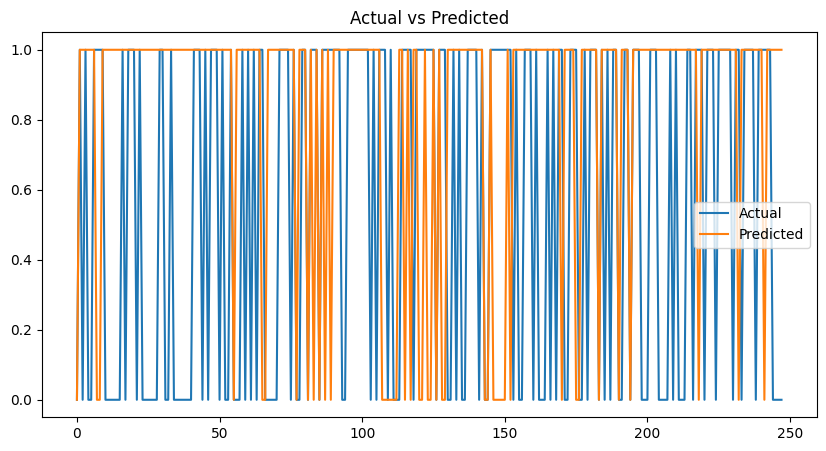

In [27]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

## Scaling

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

# 🔢 8. Encoding Techniques

We simulate categorical features.

In [10]:
# Simulate categorical features from the datetime index
data['day_of_week'] = data.index.day_name()
data['month_name'] = data.index.month_name()

data[['day_of_week', 'month_name']].head()

Price,day_of_week,month_name
Ticker,,
Date,,
2020-01-02,Thursday,January
2020-01-03,Friday,January
2020-01-06,Monday,January
2020-01-07,Tuesday,January
2020-01-08,Wednesday,January



---

## 🔹 One-Hot Encoding


In [11]:
data_onehot = pd.get_dummies(
    data,
    columns=['day_of_week', 'month_name'],
    drop_first=True
)

data_onehot.head()

,"(Close, AAPL)","(High, AAPL)","(Low, AAPL)","(Open, AAPL)","(Volume, AAPL)","(returns, )","(log_returns, )","(momentum_5, )","(momentum_10, )","(sma_10, )",...,"('month_name', '')_December","('month_name', '')_February","('month_name', '')_January","('month_name', '')_July","('month_name', '')_June","('month_name', '')_March","('month_name', '')_May","('month_name', '')_November","('month_name', '')_October","('month_name', '')_September"
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400,NaN,NaN,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,False,False
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800,-0.009722,-0.009770,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,False,False
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200,0.007968,0.007937,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,False,False
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,-0.004703,-0.004714,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,False,False
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,0.016086,0.015958,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,False,False



---

## 🔹 Label Encoding

In [12]:
from sklearn.preprocessing import LabelEncoder

le_day = LabelEncoder()
le_month = LabelEncoder()

data['day_of_week_label'] = le_day.fit_transform(data['day_of_week'])
data['month_name_label'] = le_month.fit_transform(data['month_name'])

data[['day_of_week', 'day_of_week_label', 'month_name', 'month_name_label']].head()

Price,day_of_week,day_of_week_label,month_name,month_name_label
Ticker,,,,
Date,,,,
2020-01-02,Thursday,2,January,4
2020-01-03,Friday,0,January,4
2020-01-06,Monday,1,January,4
2020-01-07,Tuesday,3,January,4
2020-01-08,Wednesday,4,January,4




---

## 🔹 Target Encoding

In [13]:
# Simulated target: whether next day's return is positive
data['target'] = (data['Close'].squeeze().shift(-1) > data['Close'].squeeze()).astype(int)

# Target encoding
day_target_map = data.groupby('day_of_week')['target'].mean()
month_target_map = data.groupby('month_name')['target'].mean()

data['day_of_week_target_enc'] = data['day_of_week'].map(day_target_map)
data['month_name_target_enc'] = data['month_name'].map(month_target_map)

data[['day_of_week', 'day_of_week_target_enc', 'month_name', 'month_name_target_enc']].head()

Price,day_of_week,day_of_week_target_enc,month_name,month_name_target_enc
Ticker,,,,
Date,,,,
2020-01-02,Thursday,0.501961,January,0.514851
2020-01-03,Friday,0.567460,January,0.514851
2020-01-06,Monday,0.553648,January,0.514851
2020-01-07,Tuesday,0.526923,January,0.514851
2020-01-08,Wednesday,0.515504,January,0.514851



---

# ⚖️ 9. Feature Scaling

## 📌 Why?

Different scales → model instability

---

## 🔹 Standard Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

standard_cols = ['returns', 'momentum_5', 'momentum_10', 'volatility_10']
data_standard_scaled = data.copy()

data_standard_scaled[standard_cols] = standard_scaler.fit_transform(
    data_standard_scaled[standard_cols].fillna(0)
)

data_standard_scaled[standard_cols].head()

Price,returns,momentum_5,momentum_10,volatility_10
Ticker,,,,
Date,,,,
2020-01-02,-0.059237,-0.126803,-0.177254,-1.774717
2020-01-03,-0.546811,-0.126803,-0.177254,-1.774717
2020-01-06,0.340383,-0.126803,-0.177254,-1.774717
2020-01-07,-0.295095,-0.126803,-0.177254,-1.774717
2020-01-08,0.747507,-0.126803,-0.177254,-1.774717



---

## 🔹 MinMax Scaling


In [15]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

minmax_cols = ['returns', 'momentum_5', 'momentum_10', 'volatility_10']
data_minmax_scaled = data.copy()

data_minmax_scaled[minmax_cols] = minmax_scaler.fit_transform(
    data_minmax_scaled[minmax_cols].fillna(0)
)

data_minmax_scaled[minmax_cols].head()

Price,returns,momentum_5,momentum_10,volatility_10
Ticker,,,,
Date,,,,
2020-01-02,0.517788,0.447323,0.500131,0.0
2020-01-03,0.478657,0.447323,0.500131,0.0
2020-01-06,0.549859,0.447323,0.500131,0.0
2020-01-07,0.498859,0.447323,0.500131,0.0
2020-01-08,0.582533,0.447323,0.500131,0.0


---

## 🔹 Robust Scaling

In [16]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

robust_cols = ['returns', 'momentum_5', 'momentum_10', 'volatility_10']
data_robust_scaled = data.copy()

data_robust_scaled[robust_cols] = robust_scaler.fit_transform(
    data_robust_scaled[robust_cols].fillna(0)
)

data_robust_scaled[robust_cols].head()

Price,returns,momentum_5,momentum_10,volatility_10
Ticker,,,,
Date,,,,
2020-01-02,-0.057781,-0.126565,-0.181993,-1.575398
2020-01-03,-0.534058,-0.126565,-0.181993,-1.575398
2020-01-06,0.332579,-0.126565,-0.181993,-1.575398
2020-01-07,-0.288175,-0.126565,-0.181993,-1.575398
2020-01-08,0.730270,-0.126565,-0.181993,-1.575398


---

# 🔗 10. Pipeline-Based Preprocessing

## 📌 Concept

Pipeline = **automated, reproducible workflow**

---

## 🧪 Implementation

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Build a clean dataframe with only the columns needed
pipeline_data = pd.DataFrame({
    'returns': data['returns'].iloc[:, 0] if isinstance(data['returns'], pd.DataFrame) else data['returns'],
    'momentum_5': data['momentum_5'].iloc[:, 0] if isinstance(data['momentum_5'], pd.DataFrame) else data['momentum_5'],
    'momentum_10': data['momentum_10'].iloc[:, 0] if isinstance(data['momentum_10'], pd.DataFrame) else data['momentum_10'],
    'volatility_10': data['volatility_10'].iloc[:, 0] if isinstance(data['volatility_10'], pd.DataFrame) else data['volatility_10'],
    'day_of_week': data['day_of_week'].iloc[:, 0] if isinstance(data['day_of_week'], pd.DataFrame) else data['day_of_week'],
    'month_name': data['month_name'].iloc[:, 0] if isinstance(data['month_name'], pd.DataFrame) else data['month_name'],
})

numeric_features = ['returns', 'momentum_5', 'momentum_10', 'volatility_10']
categorical_features = ['day_of_week', 'month_name']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

processed_data = preprocessor.fit_transform(pipeline_data)

print(processed_data.shape)

(1258, 21)



---

# 📈 11. Final Insights

### 🔥 Key Learnings

* Raw data ≠ useful → features create signal
* Financial data is:

  * Non-normal
  * Skewed
  * Noisy

---

### ⚠️ Common Mistakes

* Applying scaling before train-test split
* Using target encoding without CV
* Ignoring skewness

---

### 💡 Pro Tips

* RobustScaler > StandardScaler (finance)
* Domain features > random features
* Pipelines = must for ML systems

---



---

# 🎯 Final Summary

This project demonstrates:

- ✔ Feature creation
- ✔ Transformation (log, Box-Cox)
- ✔ Skew handling
- ✔ Domain-driven design
- ✔ Encoding (OneHot, Label, Target)
- ✔ Scaling techniques
- ✔ Pipeline engineering

---

